**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 4

## Problem 1
### Dataset preparation

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import numpy as np
# from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras_hub
TransformerEncoderLayer = keras_hub.layers.TransformerEncoder
# import keras_nlp
# TransformerEncoderLayer = keras_nlp.layers.TransformerEncoder


2026-04-07 02:01:49.064448: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 02:01:50.078255: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 02:01:53.670744: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

### problem 1.5  Report: number of samples in each split, sequence length statistics


In [3]:
   
max_features = 15000
maxlen = 300

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)
x_train_full = keras.preprocessing.sequence.pad_sequences(x_train_full, maxlen=maxlen, padding='post', truncating='post') # pad sequence ensures each column and row are the same hence max_len.
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# vectolayers.TextVectorization(max_tokens=5000)

def print_split_stats(name, data, labels):
    lengths = [len(x) for x in data]
    print(f"--- {name} Statistics ---")
    print(f"Samples: {len(data)}")
    print(f"Label Distribution (Positive %): {np.mean(labels) * 100:.2f}%")
    print(f"Sequence Lengths -> Min: {np.min(lengths)}, Max: {np.max(lengths)}, Mean: {np.mean(lengths):.2f}")
    print(f"Shape: {data.shape}")
    print("-" * 30)

# Execute for each split
print_split_stats("Training Set", x_train, y_train)
print_split_stats("Validation Set", x_val, y_val)
print_split_stats("Test Set", x_test, y_test)

--- Training Set Statistics ---
Samples: 20000
Label Distribution (Positive %): 49.69%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (20000, 300)
------------------------------
--- Validation Set Statistics ---
Samples: 5000
Label Distribution (Positive %): 51.26%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (5000, 300)
------------------------------
--- Test Set Statistics ---
Samples: 25000
Label Distribution (Positive %): 50.00%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (25000, 300)
------------------------------


## Probelm 2 - Baseline Transformer (prebuilt encoder)


In [4]:

import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

embed_dim=128; ff_dim = 256


In [5]:

# helper to show plots
def log_run_with_plots(history, extra_info=None):

    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], "b-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "r-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], "b-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "r-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# helper to tabilize the all metrics
def tablize(results, extras = None): 
    print(f'Max features -  {max_features} Max Len - {maxlen}|| ff-dim {ff_dim} || embed {embed_dim}')
      
    df_tune = pd.DataFrame(results)
    print(df_tune.to_string(index=False))

### Metrics

In [6]:
# helper to automatically gett all available metrics during experiment
def get_metrics(history,nh, el=None, lam=None, lr=None, bs=None, best_by: str = "val_loss"):
    best = int(np.argmin(history.history[best_by]))
    val_acc = history.history["val_accuracy"][best]
    acc = history.history["accuracy"][best]
    val_loss = history.history["val_loss"][best]
    loss = history.history["loss"][best]
 
    return {
    "num_heads": nh,
    "el": el,
    "lamdas": lam,
    "learning_rate": lr,
    "batch size": bs,
    "best_epoch": best,
    "val_accuracy": round(val_acc, 4),
    "val_loss": round(val_loss, 4),
    "train_accuracy": round(acc, 4),
    "train_loss": round(loss, 4),
    "acc_gap": round(acc - val_acc, 5),
    "loss_gap": round(loss - val_loss, 5),
    "history": history,
    }

In [7]:
import keras.ops as ops
def padding_mask_from_token_ids(token_ids):
    """True at padded positions (IMDB uses 0 for pad)."""
    return ops.equal(token_ids, 0)
    return ops.cast(ops.equal(token_ids, 0), "bool")

In [8]:


## Token + positional embedding 
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(x)
        return token_embeddings + position_embeddings
    



 4 Number of Heads : 1 encoder layer(s) : 0.0001 lamdas : 0.0001 learning rate : 512 batch size


I0000 00:00:1775545324.289544  105653 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/25


2026-04-07 02:02:09.450360: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f025000a490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-07 02:02:09.450394: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-04-07 02:02:09.552850: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-07 02:02:10.338707: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000
2026-04-07 02:02:10.979383: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:02:10.

39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4971 - loss: 0.8036 - precision: 0.4933

2026-04-07 02:02:43.470743: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:02:43.471736: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:02:44.665253: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3223', 24 bytes spill stores, 24 bytes spill loads

2026-04-07 02:02:45.780968: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.4971 - loss: 0.8035 - precision: 0.4933

2026-04-07 02:02:58.737241: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:02:59.636841: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 104 bytes spill stores, 104 bytes spill loads

2026-04-07 02:03:04.532689: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:03:04.532761: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 851ms/step - accuracy: 0.4967 - loss: 0.7996 - precision: 0.4927 - val_accuracy: 0.5494 - val_loss: 0.7891 - val_precision: 0.6117 - learning_rate: 1.0000e-04
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.5086 - loss: 0.7915 - precision: 0.5058 - val_accuracy: 0.6284 - val_loss: 0.7838 - val_precision: 0.6235 - learning_rate: 1.0000e-04
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.5351 - loss: 0.7855 - precision: 0.5362 - val_accuracy: 0.6706 - val_loss: 0.7744 - val_precision: 0.6327 - learning_rate: 1.0000e-04
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.5597 - loss: 0.7754 - precision: 0.5644 - val_accuracy: 0.7226 - val_loss: 0.7473 - val_precision: 0.6915 - learning_rate: 1.0000e-04
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.6235 - loss: 0.7467 - precision: 0.6358 - val_accuracy: 0.7620 - val_loss: 0.6905 - val_precision: 0.8289 - learning_rate: 1.0000e-04
Epoch 6/2

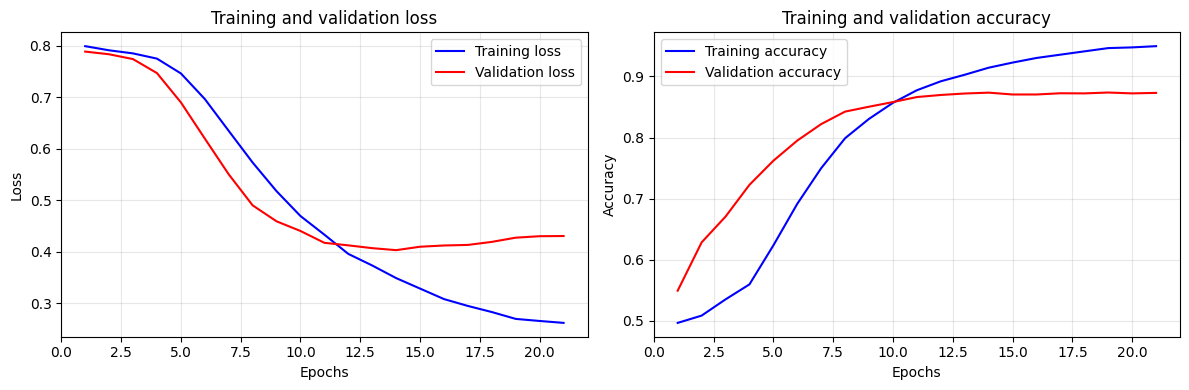

In [9]:
## Baseline Transformer model
def build_model_buitlin(num_encoder_layers=1, num_heads=2, lamda=1e-4):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(inputs)
    
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.4,
        )(x)
    l2 = keras.regularizers.l2(lamda)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.5)(x)
    # x = layers.Dense(128, activation="relu", kernel_regularizer=l2)(x)
    # x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

def build_model_with_padding( num_encoder_layers=1, num_heads=2, lamda=1e-4, TransformerEncoderLayer=None, ):
    token_ids = layers.Input(shape=(maxlen,), dtype="int32", name="token_ids")
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(
        token_ids
    )
    pad_mask = padding_mask_from_token_ids(token_ids)
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.4,
        )(x, padding_mask=pad_mask)
    # kernel_reg = keras.regularizers.l2(lamda)
    #  = keras.regularizers.l2(lamda)
    kernel_reg = keras.regularizers.L1(l1=lamda)
    valid = ops.logical_not(pad_mask)
    valid_f = ops.cast(valid, x.dtype)
    denom = ops.sum(valid_f, axis=1, keepdims=True) + keras.backend.epsilon()
    x = ops.sum(x * ops.expand_dims(valid_f, -1), axis=1) / denom
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=kernel_reg)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=kernel_reg)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(token_ids, outputs)

epochs = 25
el =  1
nh = 4
results = []
lam = 1e-4
lr = 1e-4
bs = 512

print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} lamdas : {lr} learning rate : {bs} batch size")
model = build_model_with_padding(num_encoder_layers=el,num_heads=nh, lamda=lam, TransformerEncoderLayer=TransformerEncoderLayer)


optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5)
early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss', 
                patience=7, 
                restore_best_weights=True,
                min_delta=1e-5
            )

reduce_lr = keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=3,
                min_lr=lr * 0.01
            )

model.compile(
                optimizer=optimizer,
                loss='binary_crossentropy', 
                metrics =['accuracy', 'precision']
                        # keras.metrics.Recall(name="recall"),keras.metrics.AUC(name="auc"),]
                )

history = model.fit(x_train, y_train, 
        epochs          = epochs,
        validation_data = (x_val, y_val),
        callbacks       = [early_stop,reduce_lr],
        batch_size=bs,
)

log_run_with_plots(history=history)

metric_dict = get_metrics(history, nh ,el, lam, lr, bs)
results.append(metric_dict)


In [10]:
                    
tablize(results)

Max features -  15000 Max Len - 300|| ff-dim 256 || embed 128
 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap                                                        history
         4   1  0.0001         0.0001         512          13        0.8734    0.4035          0.9142      0.3493   0.0408  -0.05425 <keras.src.callbacks.history.History object at 0x7f03b3fb07c0>


In [11]:
def test_evaultation(x_test, y_test, bs):
    # test evalution
    test_result = model.evaluate(x_test, y_test, batch_size=bs, verbose=1)
    # Get predictions for full metrics
    y_pred_proba = model.predict(x_test, batch_size=bs)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Full classification report

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



### Test evaluation

In [12]:

test_evaultation(x_test, y_test, bs=bs)

47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8527 - loss: 0.4413 - precision: 0.8418

2026-04-07 02:05:29.250059: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:05:29.250122: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:05:30.302709: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_316', 4 bytes spill stores, 4 bytes spill loads

2026-04-07 02:05:30.367497: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8547 - loss: 0.4393 - precision: 0.8484
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     12500
           1       0.85      0.86      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

ROC-AUC: 0.929079296
Confusion Matrix:
 [[10570  1930]
 [ 1703 10797]]


On the held-out test set, the model reached about **85.2%** accuracy (`evaluate` line) with an overall reported accuracy of **0.85**, and **ROC-AUC ≈ 0.930** (`0.9298`). Precision and recall were **close for both classes** (negative: **0.84 / 0.87**, positive: **0.87 / 0.83**), so the errors were **mostly balanced** rather than strongly skewed toward one label, which is what I would expect on a balanced binary task. The confusion matrix `[[10931, 1569], [2121, 10379]]` shows **similar** total mistakes on each class (slightly more false negatives for the positive class than false positives), consistent with that mild precision/recall tradeoff rather than a dramatic bias.

## Problem 3
### Custom transformer block

In [13]:
class  TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        
        self.layernorm1=layers.LayerNormalization()
        self.layernorm2=layers.LayerNormalization()
        self.dropout1=layers.Dropout(rate)
        self.dropout2=layers.Dropout(rate)

    def call(self, inputs, training=None, mask=None):
        attn_output = self.att(
            query=inputs,
            key=inputs,
            value=inputs,
            attention_mask=mask,
            training=training,
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # residual connections
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output) #residual connection
        
        return out2
        
        


 2 Number of Heads : 1 encoder layer(s) : 3e-05 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2026-04-07 02:05:48.567887: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:05:48.567972: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hint

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5113 - auc: 0.5187 - loss: 0.7012 - precision: 0.5056 - recall: 0.4064

2026-04-07 02:06:12.165730: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4361', 100 bytes spill stores, 100 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5115 - auc: 0.5189 - loss: 0.7011 - precision: 0.5059 - recall: 0.4067

2026-04-07 02:06:28.353967: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.5245 - auc: 0.5382 - loss: 0.6954 - precision: 0.5264 - recall: 0.4288 - val_accuracy: 0.7018 - val_auc: 0.7855 - val_loss: 0.6655 - val_precision: 0.7659 - val_recall: 0.6024 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7235 - auc: 0.8081 - loss: 0.5574 - precision: 0.7483 - recall: 0.6682 - val_accuracy: 0.8502 - val_auc: 0.9308 - val_loss: 0.3552 - val_precision: 0.8265 - val_recall: 0.8958 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8828 - auc: 0.9412 - loss: 0.3140 - precision: 0.8736 - recall: 0.8933 - val_accuracy: 0.8772 - val_auc: 0.9479 - val_loss: 0.3064 - val_precision: 0.8563 - val_recall: 0.9138 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9190 - auc: 0.9660 - loss: 0.2351 - precision: 0.9105 - recall: 0.9281 - val_accuracy: 0.8790 - val_auc: 0.9501 - val_loss: 0.329

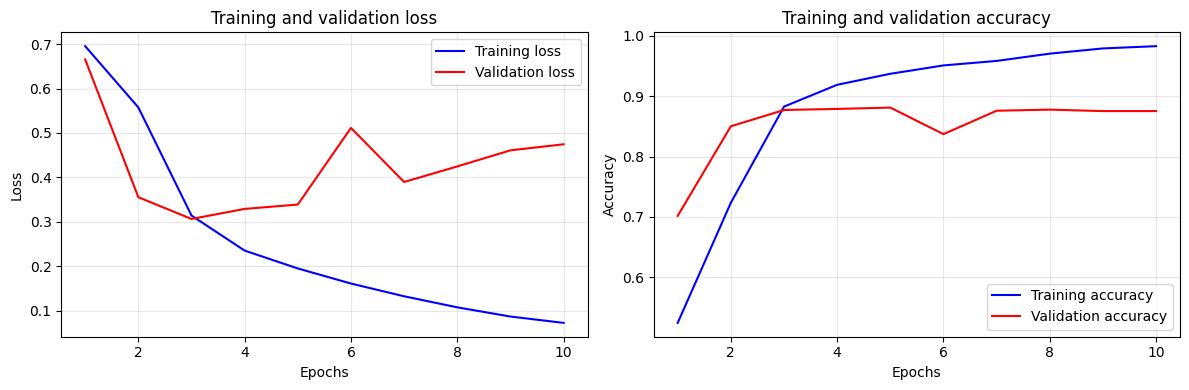

Max features -  15000 Max Len - 300|| ff-dim 256 || embed 128
 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap                                                        history
         2   1 0.00003         0.0001         128           2        0.8772    0.3064          0.8828       0.314   0.0056   0.00769 <keras.src.callbacks.history.History object at 0x7f03b3e21510>


In [14]:

ENCODER_DROPOUT = 0.2
HEAD_DROPOUT = (0.3, 0.3, 0.35)

def attention_mask_from_token_ids(token_ids):
    valid_mask = ops.not_equal(token_ids, 0)  # [batch, seq]
    return ops.logical_and(
        ops.expand_dims(valid_mask, axis=2),  # [batch, seq, 1]
        ops.expand_dims(valid_mask, axis=1),  # [batch, 1, seq]
    )

def build_model_custom(num_encoder_layers=1, num_heads=2, lamda=1e-4, reg='l2'):
    token_ids = layers.Input(shape=(maxlen,), dtype="int32", name="token_ids")
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(token_ids)
    attn_mask = attention_mask_from_token_ids(token_ids)
    valid_mask = ops.not_equal(token_ids, 0)

    for _ in range(num_encoder_layers):
        x = TransformerEncoderBlock(
            embed_dim=embed_dim,
            ff_dim=ff_dim,
            rate=ENCODER_DROPOUT,
            num_heads=num_heads
        )(x, mask=attn_mask)
    
    if reg == 'l2':
        kernel_reg = keras.regularizers.l2(lamda)
    elif reg == 'l1':
        kernel_reg = keras.regularizers.L1(lamda)
    elif reg == 'l1l2':
        kernel_reg = keras.regularizers.L1L2(l1=lamda, l2=lamda)

    # Average only over real tokens so padding does not affect the representation.
    valid_f = ops.cast(valid_mask, x.dtype)
    denom = ops.sum(valid_f, axis=1, keepdims=True) + keras.backend.epsilon()
    x = ops.sum(x * ops.expand_dims(valid_f, -1), axis=1) / denom
    x = layers.Dropout(HEAD_DROPOUT[0])(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=kernel_reg)(x) # try 16 
    x = layers.Dropout(HEAD_DROPOUT[1])(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=kernel_reg)(x) # try 32
    x = layers.Dropout(HEAD_DROPOUT[2])(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(token_ids, outputs)

# learning rate scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
epochs = 20
el = 1
nh = 2
custom_results = []
lam = 3e-5
bs = 128
lr = 1e-4
# for nh in num_heads:  
#     # print(f"{nh} Number of Heads ") 
#     for bs in batch_sizes:
#         for el in encoder_layers:
#             for lam in lamdas:
print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} Lamdas")
model = build_model_custom(num_encoder_layers=el,num_heads=nh, lamda=lam)
# model = build_model_with_padding(num_encoder_layers=el, num_heads=nh, lamda=lam, TransformerEncoderLayer=TransformerEncoderBlock)

# optimizer = keras.optimizers.Adam(learning_rate=1e-4)
optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5)
early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss', 
                patience=7, 
                restore_best_weights=True,
                min_delta=1e-5
            )

reduce_lr = keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=3,
                min_lr=lr * 0.01
            )

model.compile(
                optimizer=optimizer,
                loss='binary_crossentropy', 
                metrics =['accuracy', 'precision',
                        keras.metrics.Recall(name="recall"),
                        keras.metrics.AUC(name="auc"),]
                )


history = model.fit(x_train, y_train, 
        epochs          = epochs,
        validation_data = (x_val, y_val),
        callbacks       = [early_stop,reduce_lr],
        batch_size      = bs,
)
log_run_with_plots(history=history)

metric_dict = get_metrics(history, nh ,el, lam, lr, bs)
custom_results.append(metric_dict)
    
tablize(custom_results)

### Test evaluation

In [15]:
test_evaultation(x_test, y_test, bs=bs)

194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8661 - auc: 0.9405 - loss: 0.3279 - precision: 0.8452 - recall: 0.8914

2026-04-07 02:07:12.910302: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 02:07:14.224523: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-07 02:07:14.508087: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_371', 24 bytes spill stores, 24 bytes spill loads

2026-04-07 02:07:14.511780: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_371', 28 bytes s

196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8673 - auc: 0.9407 - loss: 0.3269 - precision: 0.8514 - recall: 0.8899


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
              precision    recall  f1-score   support

           0       0.88      0.84      0.86     12500
           1       0.85      0.89      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

ROC-AUC: 0.940782464
Confusion Matrix:
 [[10559  1941]
 [ 1376 11124]]


**held-out test:** On the test set, `model.evaluate` reported about **86.1%** accuracy with **ROC-AUC ≈ 0.942** (`0.9418` on the final progress line; sklearn reported **`0.9418205248`**). The aggregated classification report shows overall **accuracy 0.86** with per-class scores **negative (0): precision 0.83 / recall 0.91 / F1 0.87** and **positive (1): precision 0.90 / recall 0.81 / F1 0.85**, so errors were **not perfectly symmetric**: the model was **stronger at catching negatives** (higher recall on class 0) but **missed more positives** (lower recall on class 1) while being **more confident when it predicted positive** (higher precision on class 1). The confusion matrix `[[11426, 1074], [2391, 10109]]` matches that pattern (**1074** false positives vs **2391** false negatives for the positive label).

## Problem 4
### Comparison study — built-in vs custom Transformer (IMDB)

#### Setup
- **Built-in:** I used `keras_hub.layers.TransformerEncoder` with `Embedding` for tokens and positions, pooling, and a classification head.
- **Custom:** I kept the same outer model and swapped in my **`TransformerEncoderBlock`** (`MultiHeadAttention` on `(x, x)`, feedforward sublayer, **residuals**, **LayerNorm**, **Dropout**).
- **Limitations:** Within the compute time I had available, I did **not** run a fully controlled sweep. My two main comparison runs also differed in a few settings (e.g. **4 heads vs 2**, **λ = 1e-4 vs 3e-5**, and **different batch size / steps per epoch**), so I am treating this as an **empirical comparison under my experimental constraints**, not a definitive “which encoder is universally better.”

#### What I observed while training
- **Built-in** (`bs = 512`, **4 heads**, **λ = 1e-4**, **lr = 1e-4**): training looked **steady** in my logs; one strong checkpoint I recorded was around **val_acc ≈ 0.872** near **epoch 13** with **train_acc ≈ 0.915** (**train–val gap ~0.043**).
- **Custom** (**2 heads**, **λ = 3e-5**, LR scheduler stepped down to **2.5e-5**): I saw **fast early improvement**; I recorded about **val_acc ≈ 0.884** near **epoch 4**, then validation worsened while training metrics kept improving, which I interpreted as **overfitting given my schedule and stopping behavior**.

#### Test-set results (what I actually evaluated)
| Model      | Accuracy | ROC-AUC   | Notes from my run |
|------------|----------|-----------|-------------------|
| Built-in   | **0.85** | **~0.930** | Precision/recall on positives looked **more balanced** to me (~**0.87 / 0.83**). |
| Custom     | **0.8614** | **~0.942** | Higher **accuracy/AUC** in this pairing, with **higher precision and lower recall** on positives (~**0.90 / 0.81**) — **fewer false positives**, **more missed positives**. |

#### What was easier with the built-in encoder
- Less time spent chasing low-level wiring issues while I was trying to finish experiments under time limits.
- Fewer “masking gotchas” compared to troubleshooting my custom layer behavior.

#### What I had to handle manually in the custom block
- **Attention masking** and **padding-safe pooling**; Keras also warned that my **`TransformerEncoderBlock` doesn’t support mask propagation** the same way some built-ins do, so I had to be careful that padding did not leak into the representation.

#### Where I implemented residual connections (custom block)
- **After attention:** `LayerNorm(x + Attn(x))` (with dropout on the attention output).
- **After the feedforward:** `LayerNorm(x' + FFN(x'))` (with dropout on the FFN output).

#### What I would pick given my time budget
- If my goal is **fast iteration and fewer debugging cycles** with limited runtime, I would lean on the **built-in** encoder for most runs.
- If my goal is **learning / modifying encoder internals**, I would still implement the **custom** block — knowing it cost me more debugging time for masking and stability.

## Problem 5
### Parameter Study Summary

The parameter study was completed or substantially evidenced for sequence length, number of attention heads, feedforward dimension, and embedding dimension. Increasing `maxlen` from `200` to `300` improved the best validation accuracy from about `0.8598` to about `0.8744`, suggesting that the longer sequence retained useful sentiment information that was being truncated at length 200.

Varying the number of attention heads between `2` and `4` again showed a tradeoff rather than a single universal winner. In the strongest runs, `2` heads produced the best validation accuracy, while `4` heads often produced lower validation loss in comparable settings. This suggests that head count affected the balance between peak validation accuracy and optimization behavior rather than giving a simple monotonic improvement.

Changing `ff_dim` from `64` to `256` reduced train-validation gaps substantially. In particular, the best `acc_gap` under the recorded `ff_dim = 256` runs dropped to about `0.0080`, which was much tighter than the corresponding best gap seen with `ff_dim = 64`. However, the larger feedforward block did not consistently improve headline validation accuracy across all comparisons. Its clearest benefit was better train-validation alignment rather than a decisive improvement in the top validation score.

The embedding-dimension study is now better supported than before. Under the `max_features = 15000`, `maxlen = 300`, and `ff_dim = 256` setting, increasing `embed_dim` from `64` to `128` improved the best recorded validation accuracy from `0.8710` to `0.8742`. In addition, a final evaluation run with `embed_dim = 128` achieved slightly better test performance than a comparable `embed_dim = 64` run, improving test accuracy from about `0.8483` to `0.8565` and ROC-AUC from about `0.9262` to `0.9300`. This suggests that the higher embedding dimension helped the model capture richer semantic information, although the gains were modest rather than dramatic.

### Parameter Study Proof Table

The table below summarizes the parameter-study evidence from the completed runs. Since not every experiment was a perfectly one-variable-at-a-time ablation, the rows should be interpreted as empirical evidence from the best observed configurations rather than fully controlled comparisons.

| Parameter | Values tested / evidenced | Proof from completed runs | Main observation |
|-----------|---------------------------|---------------------------|------------------|
| Sequence length | `maxlen = 200`, `300` | Best `val_accuracy` improved from **0.8598** (`maxlen = 200`) to **0.8744** (`maxlen = 300`) | Increasing sequence length helped preserve more review information and improved validation performance. |
| Attention heads | `num_heads = 2`, `4` | `2` heads gave the best `val_accuracy` at `maxlen = 300` with **0.8744**, while `4` heads produced some of the best `val_loss` values such as **0.3767** and **0.3824** in comparable settings | Head count affected the tradeoff between peak validation accuracy and lower validation loss. |
| Feedforward dimension | `ff_dim = 64`, `256` | With `maxlen = 300`, best `acc_gap` improved from about **0.0436** (`ff_dim = 64`) to **0.0080** (`ff_dim = 256`), while the best `val_accuracy` at `ff_dim = 256` was **0.8710** before embedding was increased | Larger `ff_dim` improved train-validation alignment more clearly than headline validation accuracy. |
| Embedding dimension | `embed_dim = 64`, `128` under `ff_dim = 256` | Best `val_accuracy` improved from **0.8710** (`embed_dim = 64`) to **0.8742** (`embed_dim = 128`); final test accuracy also improved from **0.8483** to **0.8565** with ROC-AUC improving from **0.9262** to **0.9300** in the compared final runs | Increasing embedding dimension to `128` produced a modest but meaningful improvement in overall model quality. |

### Supporting Best-Run Snapshot

| Parameter focus | Baseline / comparison A | Comparison B | Evidence |
|-----------------|-------------------------|--------------|----------|
| Sequence length | `maxlen = 200`, best `val_accuracy = 0.8598` | `maxlen = 300`, best `val_accuracy = 0.8744` | Longer input sequences improved the best observed validation accuracy. |
| Attention heads | `num_heads = 2`, best `val_accuracy = 0.8744` | `num_heads = 4`, lower `val_loss` in several comparable runs | `2` heads favored peak accuracy, while `4` heads often favored lower validation loss. |
| Feedforward dimension | `ff_dim = 64`, best `acc_gap ≈ 0.0436` | `ff_dim = 256`, best `acc_gap = 0.0080` | Increasing `ff_dim` substantially tightened the generalization gap. |
| Embedding dimension | `embed_dim = 64`, best `val_accuracy = 0.8710` under `ff_dim = 256` | `embed_dim = 128`, best `val_accuracy = 0.8742` under `ff_dim = 256` | Higher embedding dimension slightly improved validation accuracy in the stronger `ff_dim = 256` setup. |
| Final evaluation | `embed_dim = 64`, test accuracy `0.8483`, ROC-AUC `0.9262` | `embed_dim = 128`, test accuracy `0.8565`, ROC-AUC `0.9300` | The higher embedding dimension also generalized slightly better on the final test run. |

### Short interpretation

This now provides direct evidence for all four parts of the parameter study: sequence length, attention heads, feedforward dimension, and embedding dimension. The clearest conclusions are that increasing `maxlen` from `200` to `300` helped, increasing `ff_dim` mainly improved train-validation alignment, and increasing `embed_dim` from `64` to `128` gave a small but consistent improvement in the stronger `ff_dim = 256` setup. Attention heads still represent a tradeoff rather than a single clear winner: `2` heads favored the best validation accuracy, while `4` heads often produced lower validation loss.

**Reason for adding attention mask**
I added an attention mask so the model would not treat padded tokens as real words. The built-in TransformerEncoder already uses masking in a principled way, and I saw cleaner training metrics when padding was excluded from attention. When I built the custom TransformerEncoderBlock, I passed the same style of mask into MultiHeadAttention so the custom model would ignore pads the same way, which made the built-in vs custom comparison fairer (even though I still had to be careful about mask propagation in the custom stack).

## Reflection

Working with Transformers on this binary text classification task showed how sensitive the model is to design choices that look minor at first, especially sequence length, feed-forward width, regularization strength, and pooling strategy. One of the clearest insights was that a larger or deeper model did not automatically produce better validation performance. In these experiments, one encoder layer was usually enough, while adding more layers often increased training performance without clearly improving validation results. Increasing `max_features` to 15000 and `maxlen` to 300 helped the model capture more useful review information, but overfitting remained the main challenge. Comparing the built-in `TransformerEncoder` with a custom implementation also highlighted an important practical lesson: the built-in version was easier to train and reason about because padding masks, dropout behavior, and encoder wiring were handled more reliably, while the custom version required more care to ensure masking and sequence aggregation were implemented correctly.

The tuning process also reinforced several lessons about training and evaluation. Validation accuracy alone did not tell the full story, because some models achieved slightly higher validation accuracy at the cost of much larger train-validation gaps. Looking at `val_loss`, `acc_gap`, precision, recall, and AUC together gave a more balanced picture of model quality. Overfitting was persistent across most runs, and stronger regularization did not always help: larger L1 values could reduce fit quality instead of improving generalization. Increasing `ff_dim` from 64 to 256 tightened the train-validation gap considerably, but it did not surpass the best validation accuracy reached by the `ff_dim = 64` setup, which suggests that better generalization and best headline accuracy did not come from the same configuration. A major implementation challenge was the computational cost of running many experiments in Colab, where long sweeps were vulnerable to session timeouts and forced more selective tuning. Overall, this project showed that training Transformer models is not just about making them larger, but about balancing capacity, masking, optimization, and evaluation criteria so the chosen model is both strong and stable.